In [1]:
from pathlib import Path
print(Path.cwd())

/content


In [2]:
%cd /content

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

/content
Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 101 (delta 47), reused 59 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 36.56 KiB | 1.59 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/Deepfake-Detection-KYC


In [3]:
!pwd
!ls

/content/Deepfake-Detection-KYC
data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [5]:
!kaggle datasets download -d xdxd003/ff-c23
!unzip -q ff-c23.zip -d data/raw/

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [02:57<00:00, 101MB/s]



In [6]:
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
!find data/raw -maxdepth 2 -type d

data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/Deepfakes
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/csv
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/NeuralTextures


In [8]:
from pathlib import Path

DATASET_PATH = Path("data/raw/FaceForensics++_C23")

print(DATASET_PATH)

data/raw/FaceForensics++_C23


In [9]:
categories = [folder.name for folder in DATASET_PATH.iterdir() if folder.is_dir()]

print("Dataset Categories:")
for category in categories:
    print("-", category)

Dataset Categories:
- original
- Deepfakes
- FaceShifter
- FaceSwap
- Face2Face
- csv
- DeepFakeDetection
- NeuralTextures


In [10]:
video_categories = [
    folder
    for folder in DATASET_PATH.iterdir()
    if folder.is_dir() and folder.name != "csv"
]

print("Video Categories:")
for category in video_categories:
    print(category.name)

Video Categories:
original
Deepfakes
FaceShifter
FaceSwap
Face2Face
DeepFakeDetection
NeuralTextures


In [11]:
for category in video_categories:

    videos = list(category.glob("*.mp4"))

    print(f"{category.name:<20} : {len(videos)} videos")

original             : 1000 videos
Deepfakes            : 1000 videos
FaceShifter          : 1000 videos
FaceSwap             : 1000 videos
Face2Face            : 1000 videos
DeepFakeDetection    : 1000 videos
NeuralTextures       : 1000 videos


In [12]:
original_videos = sorted((DATASET_PATH / "original").glob("*.mp4"))

sample_video = original_videos[0]

print("Sample Video:")
print(sample_video)

Sample Video:
data/raw/FaceForensics++_C23/original/000.mp4


In [13]:
import cv2

cap = cv2.VideoCapture(str(sample_video))

print("Video Opened:", cap.isOpened())

Video Opened: True


In [14]:
success, frame = cap.read()

print("Frame Read:", success)

if success:
    print("Frame Shape:", frame.shape)

Frame Read: True
Frame Shape: (480, 640, 3)


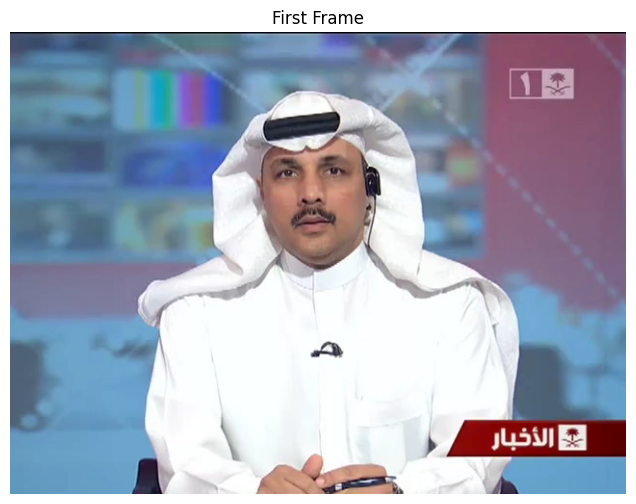

In [15]:
plt.figure(figsize=(8, 6))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

plt.title("First Frame")

plt.axis("off")

plt.show()

In [16]:
cap.release()

print("Video Closed Successfully")

Video Closed Successfully


In [22]:
def load_video(video_path):
    """
    Opens a video file using OpenCV.

    Parameters:
        video_path (str or Path): Path to the video.

    Returns:
        cv2.VideoCapture: VideoCapture object.

    Raises:
        FileNotFoundError: If the video cannot be opened.
    """

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise FileNotFoundError(f"Unable to open video: {video_path}")

    return cap

In [23]:
cap = load_video(sample_video)

print(cap.isOpened())

True


In [24]:
def is_video_valid(video_path):
    """
    Checks whether a video exists and can be opened.
    """

    cap = cv2.VideoCapture(str(video_path))

    valid = cap.isOpened()

    cap.release()

    return valid

In [25]:
print(is_video_valid(sample_video))

True


In [26]:
print(is_video_valid("fake_video.mp4"))

False


In [27]:
def get_video_info(cap):
    """
    Returns basic information about the video.
    """

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frame_count / fps if fps > 0 else 0

    return {
        "frame_count": frame_count,
        "fps": fps,
        "duration": duration,
        "width": width,
        "height": height
    }

In [28]:
cap = load_video(sample_video)

info = get_video_info(cap)

for key, value in info.items():
    print(f"{key:<12}: {value}")

frame_count : 396
fps         : 25.0
duration    : 15.84
width       : 640
height      : 480


In [29]:
def read_first_frame(cap):
    """
    Reads the first frame of a video.

    Returns:
        success (bool)
        frame (numpy.ndarray)
    """

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    success, frame = cap.read()

    return success, frame

In [30]:
success, frame = read_first_frame(cap)

print(success)
print(frame.shape)

True
(480, 640, 3)


In [31]:
def display_frame(frame, title="Frame"):
    """
    Displays a frame using matplotlib.
    """

    plt.figure(figsize=(8,6))

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    plt.title(title)

    plt.axis("off")

    plt.show()

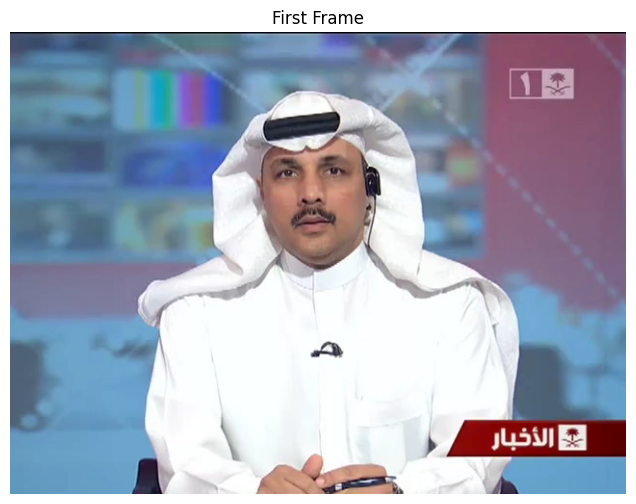

In [32]:
display_frame(frame, "First Frame")

In [33]:
def close_video(cap):
    """
    Releases the video object.
    """

    cap.release()

In [34]:
close_video(cap)

print("Video closed successfully.")

Video closed successfully.


Video Valid: True

Video Information
frame_count : 396
fps         : 25.0
duration    : 15.84
width       : 640
height      : 480


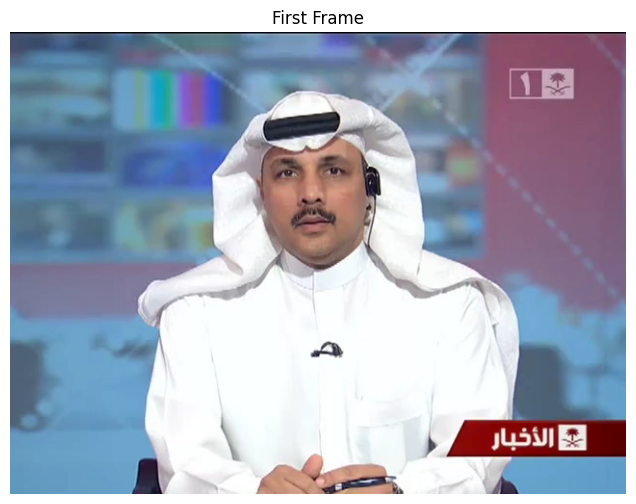

In [35]:
cap = load_video(sample_video)

print("Video Valid:", is_video_valid(sample_video))

info = get_video_info(cap)

print("\nVideo Information")

for key, value in info.items():
    print(f"{key:<12}: {value}")

success, frame = read_first_frame(cap)

if success:
    display_frame(frame, "First Frame")

close_video(cap)

In [36]:
for category in video_categories:

    video = sorted(category.glob("*.mp4"))[0]

    print("=" * 50)
    print(f"Category : {category.name}")

    cap = load_video(video)

    info = get_video_info(cap)

    print(f"Frames    : {info['frame_count']}")
    print(f"FPS       : {info['fps']}")
    print(f"Duration  : {info['duration']:.2f} sec")
    print(f"Resolution: {info['width']} x {info['height']}")

    close_video(cap)

Category : original
Frames    : 396
FPS       : 25.0
Duration  : 15.84 sec
Resolution: 640 x 480
Category : Deepfakes
Frames    : 396
FPS       : 25.0
Duration  : 15.84 sec
Resolution: 640 x 480
Category : FaceShifter
Frames    : 396
FPS       : 25.0
Duration  : 15.84 sec
Resolution: 640 x 480
Category : FaceSwap
Frames    : 303
FPS       : 25.0
Duration  : 12.12 sec
Resolution: 640 x 480
Category : Face2Face
Frames    : 303
FPS       : 25.0
Duration  : 12.12 sec
Resolution: 640 x 480
Category : DeepFakeDetection
Frames    : 1044
FPS       : 24.0
Duration  : 43.50 sec
Resolution: 1920 x 1080
Category : NeuralTextures
Frames    : 303
FPS       : 25.0
Duration  : 12.12 sec
Resolution: 640 x 480


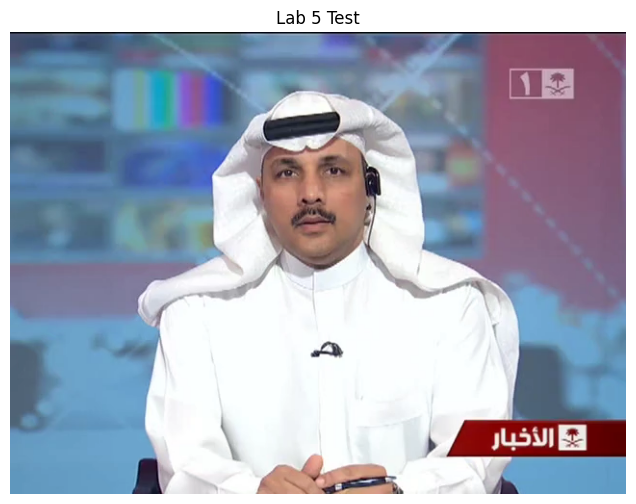

✅ All Lab 5 tests passed successfully!


In [37]:
cap = load_video(sample_video)

assert is_video_valid(sample_video)

info = get_video_info(cap)

success, frame = read_first_frame(cap)

assert success

display_frame(frame, "Lab 5 Test")

close_video(cap)

print("✅ All Lab 5 tests passed successfully!")

In [38]:
"""
video_loader.py

Author: Aishwarya Lakshmi
Project: Deepfake Detection for Video KYC

Utility functions for loading and inspecting videos
from the FaceForensics++ dataset.
"""

import cv2
import matplotlib.pyplot as plt


def load_video(video_path: str):
    """
    Opens a video file using OpenCV.

    Parameters:
        video_path (str or Path): Path to the video.

    Returns:
        cv2.VideoCapture: VideoCapture object.

    Raises:
        FileNotFoundError: If the video cannot be opened.
    """

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise FileNotFoundError(f"Unable to open video: {video_path}")

    return cap


def is_video_valid(video_path: str) -> bool:
    """
    Checks whether a video exists and can be opened.
    """

    cap = cv2.VideoCapture(str(video_path))
    valid = cap.isOpened()
    cap.release()

    return valid


def get_video_info(cap) -> dict:
    """
    Returns basic information about the video.
    """

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = round(frame_count / fps, 2) if fps > 0 else 0

    return {
        "frame_count": frame_count,
        "fps": fps,
        "duration": duration,
        "width": width,
        "height": height
    }


def read_first_frame(cap):
    """
    Reads the first frame of a video.

    Returns:
        tuple: (success, frame)
    """

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    success, frame = cap.read()

    return success, frame


def display_frame(frame, title: str = "Frame"):
    """
    Displays a frame using matplotlib.
    """

    if frame is None:
        print("No frame to display.")
        return

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def close_video(cap) -> None:
    """
    Releases the video object.
    """

    if cap is not None:
        cap.release()

In [39]:
cap = load_video(sample_video)

print(cap.isOpened())

True


In [40]:
for category in video_categories:

    video = sorted(category.glob("*.mp4"))[0]

    print("=" * 50)
    print(f"Category: {category.name}")

    cap = load_video(video)

    info = get_video_info(cap)

    print(f"Frames     : {info['frame_count']}")
    print(f"FPS        : {info['fps']}")
    print(f"Duration   : {info['duration']} sec")
    print(f"Resolution : {info['width']} x {info['height']}")

    success, frame = read_first_frame(cap)

    print("First Frame Read:", success)

    close_video(cap)

print("\n✅ All categories tested successfully.")

Category: original
Frames     : 396
FPS        : 25.0
Duration   : 15.84 sec
Resolution : 640 x 480
First Frame Read: True
Category: Deepfakes
Frames     : 396
FPS        : 25.0
Duration   : 15.84 sec
Resolution : 640 x 480
First Frame Read: True
Category: FaceShifter
Frames     : 396
FPS        : 25.0
Duration   : 15.84 sec
Resolution : 640 x 480
First Frame Read: True
Category: FaceSwap
Frames     : 303
FPS        : 25.0
Duration   : 12.12 sec
Resolution : 640 x 480
First Frame Read: True
Category: Face2Face
Frames     : 303
FPS        : 25.0
Duration   : 12.12 sec
Resolution : 640 x 480
First Frame Read: True
Category: DeepFakeDetection
Frames     : 1044
FPS        : 24.0
Duration   : 43.5 sec
Resolution : 1920 x 1080
First Frame Read: True
Category: NeuralTextures
Frames     : 303
FPS        : 25.0
Duration   : 12.12 sec
Resolution : 640 x 480
First Frame Read: True

✅ All categories tested successfully.
